In [20]:
# manipulacja danymi
import numpy as np
import pandas as pd

# wizualizacja danych
import matplotlib.pyplot as plt
import seaborn as sns

# statystyczna analiza danych
from scipy import stats

# przygotowanie danych
from sklearn.preprocessing import StandardScaler, MinMaxScaler
dataset = pd.read_csv('titanic.csv')
dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# Rachunek Prawdopodobienstwa

Tak, znowu robimy przypomnienie czegoś, co dobrze już znasz – naprawdę, podstawy analizy danych są proste! Jesteśmy pewni, że zdarzyło Ci się zetknąć już z prawdopodobieństwem w szkole lub w życiu, ale czym dokładnie jest prawdopodobieństwo i jak się je oblicza? Prawdopodobieństwo to możliwość zajścia określonego zdarzenia (A), np. wygranej na loterii lub wyrzucenia szóstki na kostce. Znalezienie prawdopodobieństwa jest proste przy użyciu wzoru prawdopodobieństwa. Wzór to nic innego, jak liczba korzystnych wyników (A) podzielona przez całkowitą liczbę wyników (Ω).

Prawdopodobieństwo można obliczyć tylko wtedy, gdy zdarzenie, którego prawdopodobieństwo obliczamy, albo się wydarzy, albo nie. Zdarzenie i jego przeciwieństwo nie mogą wystąpić w tym samym czasie. Przykładem zdarzeń wzajemnie się wykluczających jest rzucenie kostką 6. Albo wypadnie 6, albo nie. Nie może w tym samym czasie wypaść 3 oraz 6 na jednej kostce. Załóżmy, że próbujesz znaleźć prawdopodobieństwo wyrzucenia szóstki na kostce do gry. Wyrzucenie szóstki jest zdarzeniem, a ponieważ wiemy, że na kostce może wypaść dowolna z 6 liczb, liczba możliwych wyników wynosi 6. Wiemy więc, że w tym przypadku istnieje 6 możliwych zdarzeń i jeden wynik, którego prawdopodobieństwo chcemy obliczyć.

# prawdopodobienstwo calkowitew

Możemy mieć na przykład takie zadanie: 80% osób regularnie odwiedza swojego lekarza pierwszego kontaktu. U 35% z nich w ciągu następnego roku nie wystąpiły żadne problemy zdrowotne. Spośród 20% osób, które nie chodzą regularnie do lekarza, tylko 5% nie ma żadnych problemów zdrowotnych w ciągu następnego roku. Jakie jest prawdopodobieństwo, że losowo wybrana osoba nie będzie miała żadnych problemów zdrowotnych w następnym roku? Narysujmy drzewo prawdopodobieństw, dzięki temu łatwiej będzie znaleźć odpowiedź.

image
Pomnożyliśmy prawdopodobieństwa dla każdej gałęzi. Ich suma równa jest 100%. W tym zadaniu chcemy odpowiedzieć na pytanie jakie jest prawdopodobieństwo, że losowo wybrana będzie zdrowa osoba. Prawdopodobieństwo osoby zdrowej, która odwiedzi lekarza to 28%, a osoby, która go nie odwiedzi to 1%, zatem prawdopodobieństwo całkowite równe jest 29%.

# prawdopodobienstwo warunkowe 

Prawdopodobieństwo warunkowe to prawdopodobieństwo wystąpienia zdarzenia pod warunkiem wystąpienia innego zdarzenia. Jeśli zdarzenia A i B nie są niezależne, to prawdopodobieństwo przecięcia się zdarzeń A i B (prawdopodobieństwo wystąpienia obu zdarzeń) jest określone wzorem:

image
Z definicji tej wynika, że prawdopodobieństwo warunkowe P(A|B) można łatwo otrzymać, dzieląc obie strony przez prawdopodobieństwo wystąpienia zdarzenia B ~ P(B):

image
Teoria teorią, ale my wykorzystujemy statystykę czy rachunek prawdopodobieństwa w celach praktycznych. Wyobraź sobie, że pracujesz w firmie produkującej samochody sportowe. W grupie 100 nabywców samochodów sportowych 40 kupiło system alarmowy, 30 kupiło fotele kubełkowe, a 20 kupiło system alarmowy i fotele kubełkowe. Jeśli losowo wybrany nabywca samochodu kupił system alarmowy, to jakie jest prawdopodobieństwo, że kupił również fotele kubełkowe?

image
Teraz obliczmy prawdopodobieństwo. Prawdopodobieństwo zakupienia zarazem systemu alarmowego oraz fotela kubełkowego to 20%, a prawdopodobieństwo zakupienia systemu alarmowego to 40%. To nam wystarczy.

P = 0.2/0.4 = 0.5

# TWIERDZENIE BAYESA

Twierdzenie Bayesa pozwala obliczyć prawdopodobieństwo warunkowe. Jest to zwodniczo proste obliczenie, choć może być użyte do łatwego obliczenia warunkowego prawdopodobieństwa zdarzeń, w których intuicja często zawodzi. Chociaż jest to potężne narzędzie w dziedzinie prawdopodobieństwa, Twierdzenie Bayesa jest również szeroko stosowane w dziedzinie uczenia maszynowego. Na podstawie Twierdzenia Bayesa powstał Naiwny Klasyfikator Bayesowski, który był pierwszym narzędziem do klasyfikacji, czy mail, który przyszedł na Twoją skrzynkę pocztową był spamem czy nie.

akie jest prawdopodobieństwo wystąpienia choroby wątroby u pacjenta, który jest alkoholikiem? A oznacza zdarzenie, że pacjent ma chorobę wątroby. Dane z przeszłości mówią, że 10% pacjentów przychodzących do kliniki ma chorobę wątroby (P(A) = 0,10). **B **oznacza zdarzenie, że pacjent jest alkoholikiem. 5 % pacjentów kliniki to alkoholicy (P(B) = 0,05). Wiemy, że wśród pacjentów, u których zdiagnozowano chorobę wątroby, 7% to alkoholicy (P(B|A)=0.07). Chyba to nasze prawdopodobieństwo będzie wysokie, skoro 5% pacjentów kliniki to alkoholicy i aż 7% z osób mających chorobę wątroby to alkoholicy, ale czy na pewno? Policzmy to.

P(B) = P(B|A) P(A)/P(B) = 0.07 * 0.10 / 0.05 = 0.007/0.05 = 0.14

Takie prawdopodobieństwo to jedynie 14%, zupełnie inna wartość niż nasza intuicja, ale to jest prawdziwa wartość.

Cały czas obliczamy na kartce, jednak pamiętaj – to samo możesz zrobić w kodzie i zautomatyzować nasz proces. Napiszmy własną funkcję bayes_theorem i na podstawie niej obliczmy prawdopodobieństwo.

In [21]:
def bayes_theorem(p_a, p_b_given_a, p_b):
    p_a_given_b = (p_b_given_a * p_a) / p_b
    return p_a_given_b

# P(A)
p_a = 0.10

# P(B|A)
p_b_given_a = 0.07

# P(B|not A)
p_b = 0.05

# calculate P(A|B)
result = bayes_theorem(p_a, p_b_given_a, p_b)

# summarize
print('P(A|B) = %.2f%%' % (result * 100))

P(A|B) = 14.00%


# ZDARZENIA NIEZALEZNE

Aby obliczyć zdarzenia niezależne, należy traktować każde prawdopodobieństwo osobno. Po ustaleniu, jakie są te prawdopodobieństwa, obliczamy je osobno. Powiedzmy, że chcesz poznać prawdopodobieństwo dwukrotnego wyrzucenia szóstki na kostce do gry. Wiesz, że prawdopodobieństwo wyrzucenia jednej piątki jest równe 1/6, a prawdopodobieństwo wyrzucenia drugiej piątki na tej samej kości jest również równe 1/6. Pierwszy wynik nie koliduje z drugim. Zdarzenie niezależne to zdarzenie, które nie ma żadnego związku z prawdopodobieństwem wystąpienia (lub niewystąpienia) innego zdarzenia. Innymi słowy, zdarzenie to nie ma wpływu na prawdopodobieństwo wystąpienia innego zdarzenia. Zdarzenia niezależne w rachunku prawdopodobieństwa nie różnią się od zdarzeń niezależnych w życiu. To, co zjesz na śniadanie nie ma wpływu na to, czy reprezentacja Polski w piłce nożnej wygra swój najbliższy mecz.

Mamy nadzieję, że już rozumiesz czym jest niezależność zdarzeń. Aby nie zostawić niepewności, odpowiedzmy jasno czym są zdarzenia zależne. Gdy dwa zdarzenia są zależne, jedno zdarzenie wpływa na prawdopodobieństwo wystąpienia innego zdarzenia. Zdarzenie zależne to takie zdarzenie, które zależy od tego, czy inne zdarzenie wystąpi jako pierwsze. Zdarzenia zależne w prawdopodobieństwie nie różnią się od zdarzeń zależnych w prawdziwym życiu: jeśli chcesz pojechać na zagraniczne wakacje to być może zależeć będzie to od tego, czy weźmiesz nadgodziny w pracy.

# Zmienna losowa

Jest te zmienna, której wartość jest nieznana, lub funkcja, która przypisuje wartości każdemu z wyników eksperymentu. Mogą to być zmienne dyskretne (np. marka samochodu lub rzut monetą) lub zmienna ciągła (wzrost mężczyzn lub zwrot z inwestycji w spółkę).

# Rozkład dwumianowy (zwany Rozkładem Bernouliego)

Określa prawdopodobieństwo wystąpienia x sukcesów w n próbach. Eksperyment składa się z ciągu n identycznych prób, w każdej próbie możliwe są dwa wyniki – sukces (1) lub porażka (0). Prawdopodobieństwo sukcesu w dowolnej próbie, oznaczane jako p, nie zmienia się z próby na próbę oraz próby są niezależne. Załóżmy na przykład, że wiadomo, iż 10 procent właścicieli dwuletnich samochodów ma problemy z instalacją elektryczną. Aby obliczyć prawdopodobieństwo znalezienia dokładnie dwóch właścicieli, którzy mieli problemy z instalacją elektryczną w grupie 100 właścicieli, można skorzystać z rozkładu Bernouliego, ustawiając w równaniu 6 wartości n = 100, x = 2 oraz p = 0.1.

[0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0]


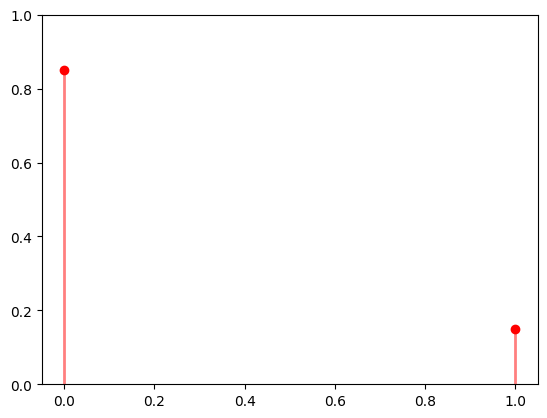

In [22]:
p = 0.1
n = 100
bern_func = stats.bernoulli.rvs(p, size=n)
print(bern_func)
bern_probability = [bern_func[bern_func==0].shape[0]/bern_func.shape[0],
                    bern_func[bern_func==1].shape[0]/bern_func.shape[0]]
plt.scatter([0, 1], bern_probability, color='red')
plt.vlines([0, 1], 0, bern_probability, color='red', lw=2, alpha=0.5)
plt.ylim([0, 1])
plt.show()

# Rozkład Poissona

Rozkład prawdopodobieństwa Poissona jest często używany jako model liczby przyjazdów do obiektu turystycznego w danym czasie. Na przykład, zmienną losową może być liczba połączeń telefonicznych przychodzących do systemu rezerwacji linii lotniczych w ciągu 15 minut. Jeśli znana jest średnia liczba przyjazdów w przedziale 15 minut, do obliczenia prawdopodobieństwa x przyjazdów można wykorzystać funkcję masy prawdopodobieństwa Poissona. Na przykład załóżmy, że średnia liczba połączeń przychodzących w piętnastominutowym przedziale czasowym wynosi 10. Obliczmy prawdopodobieństwo, że w ciągu następnych 15 minut nadejdzie 5 połączeń lub więcej, x = 10 oraz k = 5.

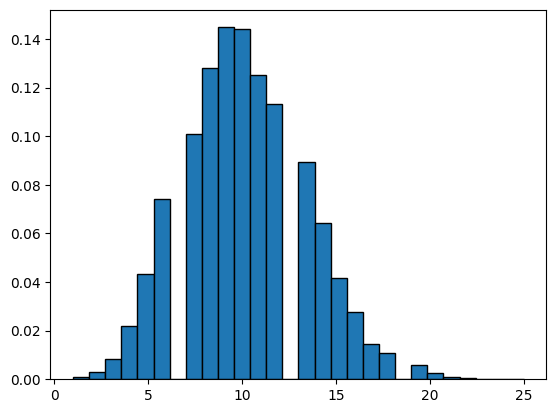

Prawdopodobieństwo, że w następnych 15 minutach będzie 5 połączeń:
0.93


In [23]:
poisson_set = stats.poisson.rvs(mu=10, size=10000)

plt.hist(poisson_set, density=True, edgecolor='black', bins=28)
plt.show()

print('Prawdopodobieństwo, że w następnych 15 minutach będzie 5 połączeń:')
print(np.round(1 - stats.poisson.cdf(k=5, mu=10), 2))

# Rozkład normalny

In [24]:
import numpy as np

Najbardziej popularny rozkład ciągły i szeroko stosowany w statystyce (nie zawsze słusznie - odwołujemy do "Czarnego Łabędzia"). Rozkład normalny oparty jest o średnią i odchylenie standardowe. Rozkład o średniej 0 i odchyleniu standardowym 1 nazywany jest rozkładem normalnym standardowym.

Stwórzmy kilka rozkładów normalnych o średniej 0 i różnym odchyleniu standardowym.

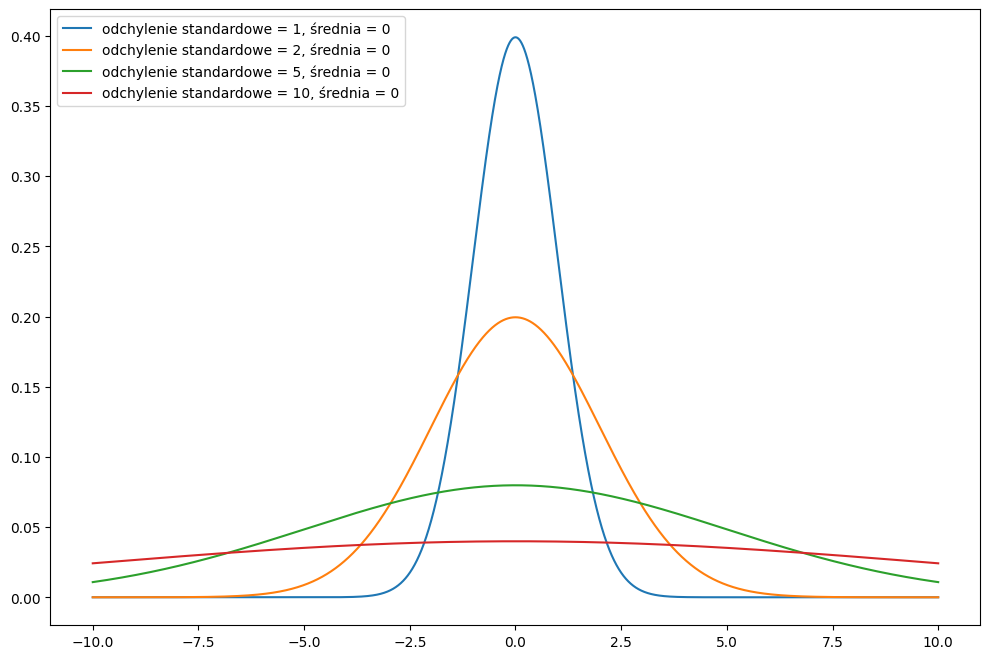

In [25]:
def gauss(x, sigma=1, mu=0):
    return stats.norm.pdf(x, mu, sigma)
x = np.linspace(-10, 10, 10000)
plt.figure(figsize=(12, 8))
plt.plot(x, gauss(x, sigma=1), label='odchylenie standardowe = 1, średnia = 0')
plt.plot(x, gauss(x, sigma=2), label='odchylenie standardowe = 2, średnia = 0')
plt.plot(x, gauss(x, sigma=5), label='odchylenie standardowe = 5, średnia = 0')
plt.plot(x, gauss(x, sigma=10), label='odchylenie standardowe = 10, średnia = 0')
plt.legend(loc='upper left')
plt.show()